# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             10000 non-null  int64
 1   gender          10000 non-null  int64
 2   height          10000 non-null  int64
 3   weight          10000 non-null  str  
 4   cholesterol     10000 non-null  int64
 5   gluc            10000 non-null  int64
 6   smoke           10000 non-null  int64
 7   alco            10000 non-null  int64
 8   active          10000 non-null  int64
 9   cardio_disease  10000 non-null  int64
dtypes: int64(9), str(1)
memory usage: 801.5 KB


In [4]:
base['weight'] = base['weight'].str.replace('.', '', regex=False)
base['weight'] = base['weight'].str.replace(',', '', regex=False)
base['weight'] = base['weight'].astype(float)

In [5]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [6]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,75.937300,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,36.867469,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,1065.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
base['gender'] = base['gender'].map({2:0, 1:1})

In [8]:
base.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,0,168,62.0,1,1,0,0,1,0
1,55,1,156,85.0,3,1,0,0,1,1
2,52,1,165,64.0,3,1,0,0,0,1
3,48,0,169,82.0,1,1,0,0,1,1
4,48,1,156,56.0,1,1,0,0,0,0


In [9]:
base['cholesterol'].unique()

array([1, 3, 2])

In [10]:
base['gluc'].unique()

array([1, 2, 3])

In [11]:
fig = px.box(base, y='height', title='BoxPlot de height')
fig.show()

In [12]:
Q1 = base['height'].quantile(0.25)
Q3 = base['height'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

base = base[(base['height'] >= limite_inferior) & (base['height'] <= limite_superior)]

mediana_sem_outliers = base['height'].median()

base.loc[
    (base['height'] < 100) | (base['height'] > limite_superior),
    'height'
] = mediana_sem_outliers

print(limite_inferior, limite_superior)

142.5 186.5


In [13]:
print(base['height'].describe())

count    9926.000000
mean      164.309792
std         7.619069
min       143.000000
25%       159.000000
50%       165.000000
75%       170.000000
max       186.000000
Name: height, dtype: float64


In [14]:
fig = px.box(base, y='height', title='BoxPlot de height')
fig.show()

In [15]:
fig = px.box(base, y='weight', title='BoxPlot de weight')
fig.show()

In [16]:
Q1 = base['weight'].quantile(0.25)
Q3 = base['weight'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

base = base[
    (base['weight'] >= limite_inferior) &
    (base['weight'] <= limite_superior)
]

In [17]:
print(base['weight'].describe())

count    9667.000000
mean       73.121651
std        12.482825
min        40.000000
25%        65.000000
50%        72.000000
75%        81.000000
max       107.000000
Name: weight, dtype: float64


In [18]:
fig = px.box(base, y='weight', title='BoxPlot de weight')
fig.show()

Utilizei o método IQR para realizar o tratamento dos outliers em 'height' e 'weight', pois havia uma distância grande entre os valores, logo optei pelo IQR pois ele faz o cálculo da dispersão com base nos quartis (Q1 e Q3). Assim, ele faz a susbstituição de valores pequenos e de valores muito altos. E observa-se no gráfico boxplot, que mesmo realizando o tratamento desses dados, ainda há alguns valores indicados como outliers, entretanto resolvi mante-los, já que não impactam nossa base de dados de modo significativo.

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


In [19]:
mediana = base.groupby('cardio_disease')['age'].median().reset_index()

fig = px.bar(mediana, x='cardio_disease', y='age',
            title='Média Age com cardio_disease')
fig.show()

Percebe-se que a média de idade das pessoas com 'cardio_disease' é de 56 anos, enquanto que para as pessoas sem a média é de 52. Ou seja, pessoas mais velhas são mais propensas a desenvolverem doenças cardiovasculares.

In [20]:
base_grouped = base.groupby(['cardio_disease', 'cholesterol']).size().reset_index(name='count')
total_por_churn = base_grouped.groupby('cardio_disease')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='cardio_disease', y='percent', color='cholesterol', barmode='stack',
            labels={'cardio_disease': 'cardio_disease', 'percent': 'Porcentagem', 'cholesterol': 'cholesterol'})

fig.update_layout(title='Relação entre cardio_disease e cholesterol',
                yaxis_title='Porcentagem',
                legend_title='cholesterol')
fig.show()

Pacientes com nível de 'cholesterol' 2 ou 3, estão mais a futuramente desenvolverem doenças cardiovascilares. Visualiza-se que 33% dos pacientes que possuem doenças cardiovasculares, estão com nível 2 ou 3 de colesterol.

In [21]:
base_grouped = base.groupby(['cardio_disease', 'gluc']).size().reset_index(name='count')
total_por_churn = base_grouped.groupby('cardio_disease')['count'].transform('sum')
base_grouped['percent'] = (base_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(base_grouped, x='cardio_disease', y='percent', color='gluc', barmode='stack',
            labels={'cardio_disease': 'cardio_disease', 'percent': 'Porcentagem', 'gluc': 'gluc'})

fig.update_layout(title='Relação entre cardio_disease e gluc',
                yaxis_title='Porcentagem',
                legend_title='gluc')
fig.show()

Pessoas com nível de 'gluc' 2 ou 3, estão mais propensos a desenvolverem doenças cardiovascilares. Visualiza-se que 17% dos pacientes que possuem doenças cardiovasculares, estão com nível 2 ou 3 de glicose.

In [22]:
mediana = base.groupby('cardio_disease')['weight'].median().reset_index()

fig = px.bar(mediana, x='cardio_disease', y='weight',
            title='Média Age com cardio_disease')
fig.show()

Observa-se que a média de 'weight' das pessoas com 'cardio_disease' é de 74, enquanto que para as pessoas sem a média é de 70. Ou seja, pessoas com maior peso estão mais propensas a desenvolverem doenças cardiovasculares.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



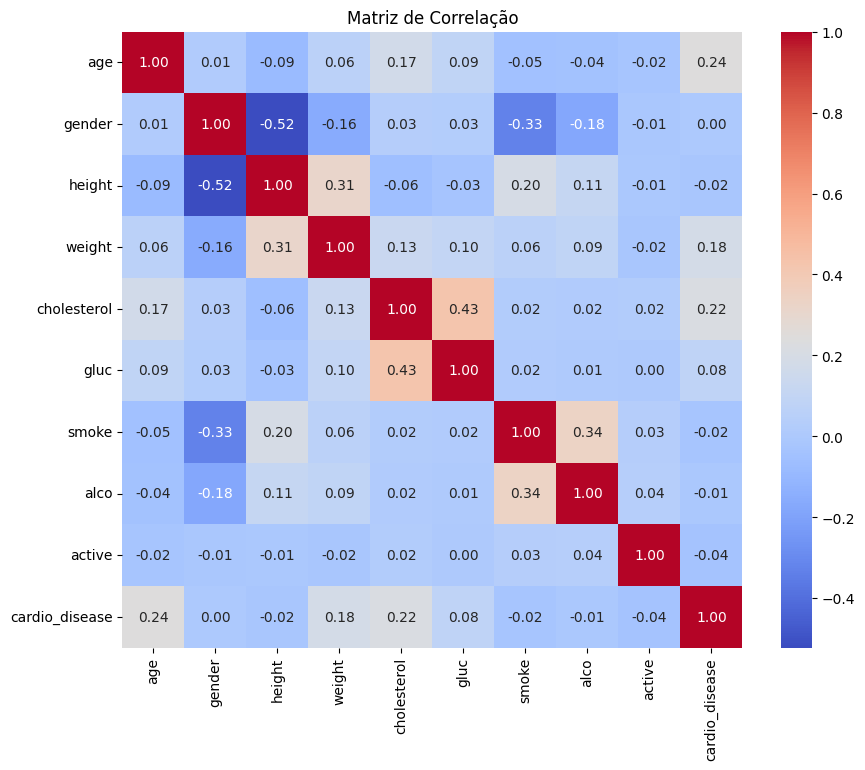

In [23]:
correlation_matrix = base.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

### Insights da Matriz de Correlação
Correlações médias:
- Gender x Height (-0,52)
- Cholesterol × Gluc (0,43)

Correlações baixas:
- Smoke x Alco (0,34)
- Height x Weight (0,31)
- Age x Cardio Disease (0,24)
- Colesterol x Cardio Disease (0,22)

### Conclusão
A matriz de correlação mostra que não há multicolinearidade. Em relação à variável alvo ('cardio_disease'), 'Age' e 'Cholesterol' são as que apresentam maior associação, apesar de ambas ainda serem relativamente fracas. Isso sugere que a ocorrência de doenças cardiovasculares depende da combinação de diversos fatores, e não apenas de uma única variável.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [24]:
X = base.drop('cardio_disease', axis=1)
Y = base['cardio_disease']

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2 ,random_state=42)

Obs: Pesquisei se havia problema manter as variáveis ordinárias, e não há problema em elas assumirem valores maiores que 1. O importante é preservar o significado das variáveis categóricas.

Realizou-se a padronização das variáveis numéricas 'age', 'height' e 'weight'. Essas variáveis apresentam escalas diferentes, podendo assumir valores muito maiores do que as demais variáveis do conjunto de dados. A padronização foi aplicada para garantir que todas contribuam de forma equilibrada para o treinamento do modelo e reduzindo possíveis impactos causados pela diferença de magnitude entre as variáveis.
As variáveis 'gender', 'smoke', 'alco' e 'active' não foram padronizadas por serem variáveis binárias. Da mesma forma, as variáveis 'cholesterol' e 'gluc' não foram padronizadas por serem variáveis categóricas ordinais, cujos valores representam níveis específicos. Optou-se por não alterar suas escalas, pois poderia dificultar a interpretação dessas categorias.

In [26]:
sc = StandardScaler()
cols = ['age', 'height', 'weight']
X_train[cols] = sc.fit_transform(X_train[cols])
X_test[cols] = sc.transform(X_test[cols])

In [ ]:
# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)

Testei o modelo com a transformção de todas as variáveis, e seu desempenho se manteve o mesmo do anterior. Logo optei por padronizar somente as variáveis com escalas diferentes.

In [27]:
base['cardio_disease'].value_counts()

cardio_disease
0    4852
1    4815
Name: count, dtype: int64

In [28]:
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [29]:
X_train_balanced

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
0,0.688459,1,-0.812862,1.682691,2,1,0,0,0
1,1.419376,0,0.241813,-0.401257,3,1,0,0,1
2,0.103725,1,-0.021856,0.400262,1,3,0,0,1
3,-0.773375,0,1.296487,0.159806,3,1,0,0,1
4,-0.773375,1,-0.285524,-0.721864,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...
7777,1.046776,0,1.237010,2.697545,1,1,0,0,1
7778,-0.050581,1,0.450553,1.059293,2,3,0,0,1
7779,1.694260,1,0.690317,-0.221782,3,1,0,0,1
7780,0.145644,1,-0.549193,-1.042471,1,1,0,0,1


In [30]:
Y_train_balanced

0       1
1       0
2       1
3       1
4       0
       ..
7777    1
7778    1
7779    1
7780    1
7781    1
Name: cardio_disease, Length: 7782, dtype: int64

In [31]:
X_test

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
5380,0.103725,1,0.505481,-0.080649,1,1,0,0,0
2478,0.542275,1,0.109978,-0.641712,3,3,0,0,0
7805,0.980825,1,-1.208365,0.239958,1,1,0,0,1
2355,-0.188641,1,-0.812862,-0.641712,2,1,0,0,1
4429,0.103725,0,1.296487,-0.481409,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...
4543,0.688459,1,0.241813,-0.160801,1,1,0,0,1
9171,0.688459,1,-0.812862,-0.481409,1,2,0,0,1
9217,0.103725,1,-0.812862,0.881173,1,3,0,0,1
9642,-0.773375,0,1.823824,-0.561560,2,2,0,0,1


In [32]:
Y_test

5380    1
2478    1
7805    0
2355    1
4429    1
       ..
4543    1
9171    0
9217    1
9642    1
4768    1
Name: cardio_disease, Length: 1934, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [33]:
logistic_cardio = LogisticRegression(random_state=0)

In [34]:
logistic_cardio.fit(X_train_balanced, Y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [35]:
logistic_cardio.intercept_

array([-0.35739697])

In [36]:
logistic_cardio.coef_

array([[ 4.56499383e-01, -1.22207541e-01, -1.44819062e-01,
         3.93249907e-01,  5.86802430e-01, -1.48229509e-01,
        -1.96871430e-01, -5.85092804e-04, -1.93269315e-01]])

In [37]:
previsoes = logistic_cardio.predict(X_train_balanced)

In [38]:
relatorio = classification_report(Y_train_balanced, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      3891
           1       0.65      0.62      0.64      3891

    accuracy                           0.64      7782
   macro avg       0.64      0.64      0.64      7782
weighted avg       0.64      0.64      0.64      7782



- A 'precision' de 0.65 para a classe 1 indica que 65% das instâncias que foram previstas como classe 1 realmente pertencem à classe 1.

- O 'recall' de 0.62 para a classe 1 indica que 62% das instâncias que pertencem à classe 1 foram corretamente identificadas pelo modelo.

- O 'f1-score' de 0.64 para a classe 1 é a média harmônica da precisão e do recall para a classe 1.

O modelo apresenta um desempenho moderado. A acurácia de 63% indica que ele consegue classificar corretamente aproximadamente 63 de cada 100 observações. As métricas de 'precision', 'recall' e 'f1-score' ficaram próximas entre si (entre 0.60 e 0.65), demonstrando que o modelo é equilibrado entre as duas classes. Ou seja, o modelo realiza previsões razoáveis, mas ainda não apresenta um desempenho alto para ser considerado um modelo de alta precisão.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [39]:
Y_pred_test = logistic_cardio.predict(X_test)

In [40]:
relatorio = classification_report(Y_test, Y_pred_test)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       961
           1       0.63      0.61      0.62       973

    accuracy                           0.62      1934
   macro avg       0.62      0.62      0.62      1934
weighted avg       0.62      0.62      0.62      1934



- O modelo apresentou uma acurácia de 0.62, indicando que acertou aproximadamente 62% das classificações realizadas no conjunto de teste.

- A precisão das duas classes ficou próxima (0.62 e 0.63), demonstrando que o modelo não favorece excessivamente uma classe em relação à outra.

- O recall da classe 0 (0.64) foi superior ao da classe 1 (0.61), indicando que o modelo consegue identificar melhor os exemplos da classe 0 do que da classe 1.

- Os valores de F1-Score ficaram próximos de 0.63, mostrando um equilíbrio razoável entre precisão e recall.

In [41]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_test)

roc_auc = roc_auc_score(Y_test, Y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.62


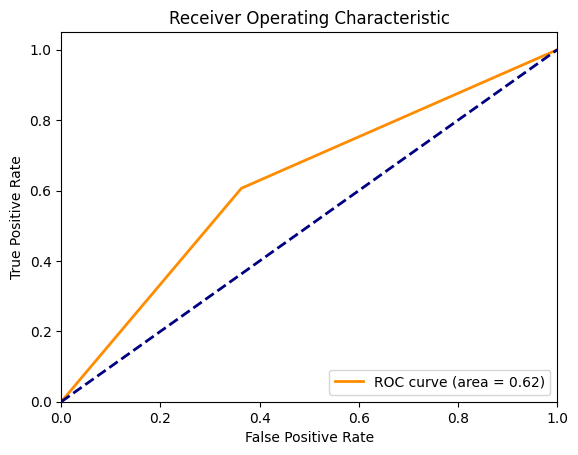

In [42]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Conclusão:

Ao comparar os resultados obtidos nos conjuntos de treinamento e teste, observa-se que o modelo de Regressão Logística apresentou um desempenho muito semelhante em ambos os casos. No treinamento, o modelo alcançou aproximadamente 64% de acurácia, com valores de precisão, recall e f1-score próximos de 0.63. Já no teste, a acurácia reduziu para 62%, e as demais métricas foram 0.61 de recall e 0.62 de f1-score. Essa consistência entre treino e teste indica que o modelo não apresenta sinais significativos de overfitting (não está apenas memorizando os dados de treinamento). Por outro lado, o nível de acerto obtido ainda é considerado moderado, já que cerca de 38% das previsões são incorretas. Isso sugere que, embora o modelo consiga capturar parte dos padrões existentes nos dados, ainda há informações ou relações que não estão sendo totalmente aproveitadas.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A) A Regressão Logística é um algoritmo de aprendizado de máquina utilizado para prever a probabilidade de um determinado evento ocorrer. Em vez de fornecer um valor numérico contínuo, ela estima a probabilidade de uma observação pertencer a uma determinada classe. E com base nessa probabilidade, o modelo realiza a classificação.

B) A Regressão Logística é considerada um modelo de classificação porque seu objetivo é prever categorias ou classes. Ela calcula a probabilidade de uma observação pertencer a uma determinada classe utilizando a função logística sigmoide, que produz valores entre 0 e 1. A partir de um limite de decisão, geralmente 0.5, o modelo define a qual classe a observação pertence.

C) A Regressão Logística e a Regressão Linear possuem várias semelhanças. Ambas utilizam uma combinação linear das variáveis independentes para realizar previsões, possuem coeficientes que representam a influência de cada variável sobre o resultado e dependem de um processo de otimização para encontrar os melhores parâmetros do modelo. Além disso, ambas exigem etapas semelhantes de preparação dos dados.